In [1]:
# 01 - Exploratory Data Analysis

## Project: Identifying Undervalued Players in the 2025-2026 Season

This notebook explores the full football player statistics dataset for the 2025-2026 season across Europe's top five leagues.

The purpose of this stage is to understand the dataset structure, assess data quality, identify missing values, explore player distributions, and prepare for later cleaning, feature engineering, clustering, and market value modelling.

## Iterative Development Approach

Initial exploration was first tested using the lighter dataset to allow faster debugging and understanding of the data structure. The project then moved to the full dataset for richer analysis and stronger feature engineering.

SyntaxError: unterminated string literal (detected at line 5) (486363927.py, line 5)

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
file_path = "../data/players_data-2025_2026.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully.
Rows: 2731
Columns: 102


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,G+A-PK,Rk_stats_keeper,Nation_stats_keeper,Pos_stats_keeper,Comp_stats_keeper,Age_stats_keeper,Born_stats_keeper,MP_stats_keeper,Starts_stats_keeper,Min_stats_keeper,90s_stats_keeper,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Rk_stats_shooting,Nation_stats_shooting,Pos_stats_shooting,Comp_stats_shooting,Age_stats_shooting,Born_stats_shooting,90s_stats_shooting,Gls_stats_shooting,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK_stats_shooting,PKatt_stats_shooting,Rk_stats_playing_time,Nation_stats_playing_time,Pos_stats_playing_time,Comp_stats_playing_time,Age_stats_playing_time,Born_stats_playing_time,MP_stats_playing_time,Min_stats_playing_time,Mn/MP,Min%,90s_stats_playing_time,Starts_stats_playing_time,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Rk_stats_misc,Nation_stats_misc,Pos_stats_misc,Comp_stats_misc,Age_stats_misc,Born_stats_misc,90s_stats_misc,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,30,24,1975,21.9,4,3,7,4,0,0,1,0,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,21.9,4,41,15,36.6,1.87,0.68,0.10,0.27,0,0,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,30,1975,66,70.8,21.9,24,77.0,2,6,21.0,1,1.00,30,26,4,0.18,1.84,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,21.9,1,0,0,17,43,5,35,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,120,1.3,0,0,0,0,0,0,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,eng ENG,DF,eng Premier League,19-331,2006.0,1.3,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,3,eng ENG,DF,eng Premier League,19-331,2006.0,2,120,60,4.3,1.3,1,75.0,0,1,45.0,11,0.00,0,4,-4,-3.00,-2.73,2,eng ENG,DF,eng Premier League,19-331,2006.0,1.3,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,638,7.1,2,0,2,2,0,0,0,0,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,ma MAR,"MF,FW",es La Liga,20-087,2006.0,7.1,2,16,4,25.0,2.26,0.56,0.13,0.50,0,0,5,ma MAR,"MF,FW",es La Liga,20-087,2006.0,20,638,32,23.6,7.1,4,75.0,1,16,21.0,10,1.55,16,11,5,0.71,0.62,3,ma MAR,"MF,FW",es La Liga,20-087,2006.0,7.1,0,0,0,5,3,2,26,3,3,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,5,0,69,0.8,0,0,0,0,0,0,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,dz ALG,"FW,MF",fr Ligue 1,26-143,1999.0,0.8,0,3,1,33.3,3.91,1.30,0.00,0.00,0,0,6,dz ALG,"FW,MF",fr Ligue 1,26-143,1999.0,5,69,14,2.7,0.8,0,NaN,0,5,14.0,2,0.80,1,5,-4,-5.22,-6.03,4,dz ALG,"FW,MF",fr Ligue 1,26-143,1999.0,0.8,1,0,0,3,0,0,1,1,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,943,10.5,2,0,2,0,2,2,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,dz ALG,MF,fr Ligue 1,26-143,1999.0,10.5,2,11,5,45.5,1.05,0.48,0.00,0.00,2,2,7,dz ALG,MF,fr Ligue 1,26-143,1999.0,13,943,73,37.4,10.5,11,81.0,4,2,25.0,0,1.38,12,13,-1,-0.10,0.59,5,dz ALG,MF,fr Ligue 1,26-143,1999.0,10.5,1,0,0,16,12,1,9,13,17,0


In [5]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts())

print("\nFirst five rows:")
display(df.head())

Dataset shape:
(2731, 102)

Column names:
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_st

float64    41
int64      40
str        21
Name: count, dtype: int64


First five rows:


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,G+A-PK,Rk_stats_keeper,Nation_stats_keeper,Pos_stats_keeper,Comp_stats_keeper,Age_stats_keeper,Born_stats_keeper,MP_stats_keeper,Starts_stats_keeper,Min_stats_keeper,90s_stats_keeper,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Rk_stats_shooting,Nation_stats_shooting,Pos_stats_shooting,Comp_stats_shooting,Age_stats_shooting,Born_stats_shooting,90s_stats_shooting,Gls_stats_shooting,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK_stats_shooting,PKatt_stats_shooting,Rk_stats_playing_time,Nation_stats_playing_time,Pos_stats_playing_time,Comp_stats_playing_time,Age_stats_playing_time,Born_stats_playing_time,MP_stats_playing_time,Min_stats_playing_time,Mn/MP,Min%,90s_stats_playing_time,Starts_stats_playing_time,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Rk_stats_misc,Nation_stats_misc,Pos_stats_misc,Comp_stats_misc,Age_stats_misc,Born_stats_misc,90s_stats_misc,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,30,24,1975,21.9,4,3,7,4,0,0,1,0,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,21.9,4,41,15,36.6,1.87,0.68,0.10,0.27,0,0,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,30,1975,66,70.8,21.9,24,77.0,2,6,21.0,1,1.00,30,26,4,0.18,1.84,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,21.9,1,0,0,17,43,5,35,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,120,1.3,0,0,0,0,0,0,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,eng ENG,DF,eng Premier League,19-331,2006.0,1.3,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,3,eng ENG,DF,eng Premier League,19-331,2006.0,2,120,60,4.3,1.3,1,75.0,0,1,45.0,11,0.00,0,4,-4,-3.00,-2.73,2,eng ENG,DF,eng Premier League,19-331,2006.0,1.3,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,638,7.1,2,0,2,2,0,0,0,0,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,ma MAR,"MF,FW",es La Liga,20-087,2006.0,7.1,2,16,4,25.0,2.26,0.56,0.13,0.50,0,0,5,ma MAR,"MF,FW",es La Liga,20-087,2006.0,20,638,32,23.6,7.1,4,75.0,1,16,21.0,10,1.55,16,11,5,0.71,0.62,3,ma MAR,"MF,FW",es La Liga,20-087,2006.0,7.1,0,0,0,5,3,2,26,3,3,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,5,0,69,0.8,0,0,0,0,0,0,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,dz ALG,"FW,MF",fr Ligue 1,26-143,1999.0,0.8,0,3,1,33.3,3.91,1.30,0.00,0.00,0,0,6,dz ALG,"FW,MF",fr Ligue 1,26-143,1999.0,5,69,14,2.7,0.8,0,NaN,0,5,14.0,2,0.80,1,5,-4,-5.22,-6.03,4,dz ALG,"FW,MF",fr Ligue 1,26-143,1999.0,0.8,1,0,0,3,0,0,1,1,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,943,10.5,2,0,2,0,2,2,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,dz ALG,MF,fr Ligue 1,26-143,1999.0,10.5,2,11,5,45.5,1.05,0.48,0.00,0.00,2,2,7,dz ALG,MF,fr Ligue 1,26-143,1999.0,13,943,73,37.4,10.5,11,81.0,4,2,25.0,0,1.38,12,13,-1,-0.10,0.59,5,dz ALG,MF,fr Ligue 1,26-143,1999.0,10.5,1,0,0,16,12,1,9,13,17,0


In [9]:
key_columns = ["Player", "Nation", "Pos", "Squad", "Comp", "Age", "MP", "Starts", "Min", "90s"]

available_key_columns = [col for col in key_columns if col in df.columns]

display(df[available_key_columns].head())

missing_key_columns = [col for col in key_columns if col not in df.columns]
print("Missing expected key columns:", missing_key_columns)

,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,90s
0,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,30,24,1975,21.9
1,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2,1,120,1.3
2,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,20,4,638,7.1
3,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,5,0,69,0.8
4,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,13,11,943,10.5


Missing expected key columns: []


In [10]:
missing_summary = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["Column", "Missing Values"]
missing_summary["Missing %"] = (missing_summary["Missing Values"] / len(df) * 100).round(2)

display(missing_summary.head(30))

,Column,Missing Values,Missing %
0,CS%,2563,93.85
1,Save%,2561,93.78
2,W,2560,93.74
3,Saves,2560,93.74
4,Rk_stats_keeper,2560,93.74
5,GA90,2560,93.74
6,D,2560,93.74
7,Starts_stats_keeper,2560,93.74
8,MP_stats_keeper,2560,93.74
9,Born_stats_keeper,2560,93.74


In [11]:
duplicate_rows = df.duplicated().sum()
duplicate_players = df.duplicated(subset=["Player", "Squad", "Comp"]).sum()

print(f"Duplicate full rows: {duplicate_rows}")
print(f"Duplicate Player-Squad-Competition records: {duplicate_players}")

Duplicate full rows: 0
Duplicate Player-Squad-Competition records: 0


In [12]:
df_eda = df.copy()

df_eda["Min"] = (
    df_eda["Min"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df_eda["Min"] = pd.to_numeric(df_eda["Min"], errors="coerce")
df_eda["Age"] = pd.to_numeric(df_eda["Age"], errors="coerce")
df_eda["90s"] = pd.to_numeric(df_eda["90s"], errors="coerce")

display(df_eda[["Player", "Squad", "Comp", "Pos", "Age", "Min", "90s"]].head())

,Player,Squad,Comp,Pos,Age,Min,90s
0,Brenden Aaronson,Leeds United,eng Premier League,"MF,FW",25.0,1975,21.9
1,Zach Abbott,Nottingham Forest,eng Premier League,DF,19.0,120,1.3
2,Jones El-Abdellaoui,Celta Vigo,es La Liga,"MF,FW",20.0,638,7.1
3,Himad Abdelli,Marseille,fr Ligue 1,"FW,MF",26.0,69,0.8
4,Himad Abdelli,Angers,fr Ligue 1,MF,26.0,943,10.5


,League,Number of Players
0,it Serie A,582
1,es La Liga,581
2,fr Ligue 1,540
3,eng Premier League,535
4,de Bundesliga,493


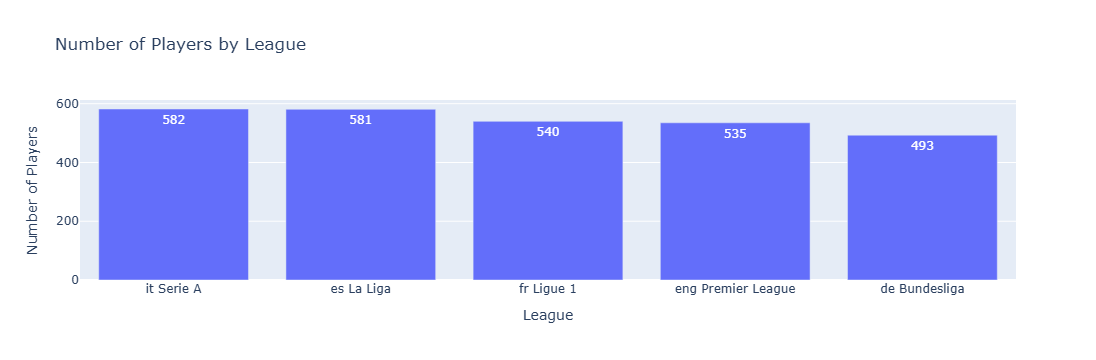

In [13]:
league_counts = df_eda["Comp"].value_counts().reset_index()
league_counts.columns = ["League", "Number of Players"]

display(league_counts)

fig = px.bar(
    league_counts,
    x="League",
    y="Number of Players",
    title="Number of Players by League",
    text="Number of Players"
)

fig.show()

,Position,Number of Players
0,MF,912
1,DF,683
2,FW,385
3,"MF,FW",195
4,GK,171
5,"FW,MF",146
6,"DF,MF",131
7,"MF,DF",105
8,"DF,FW",3


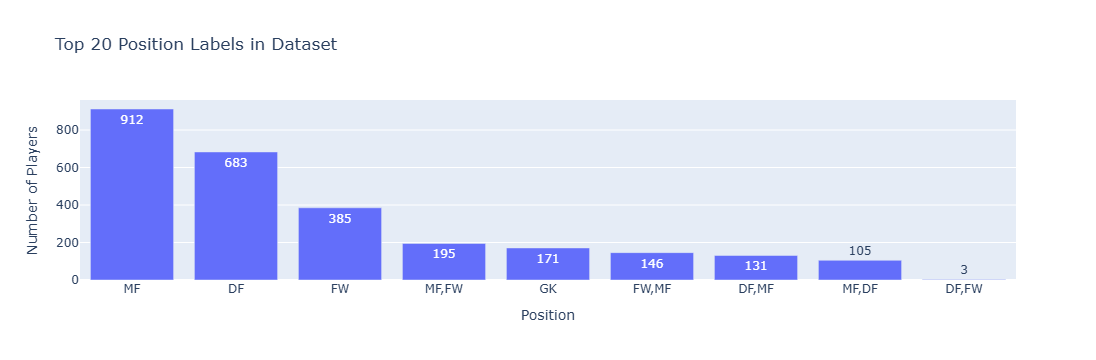

In [14]:
position_counts = df_eda["Pos"].value_counts().reset_index()
position_counts.columns = ["Position", "Number of Players"]

display(position_counts.head(20))

fig = px.bar(
    position_counts.head(20),
    x="Position",
    y="Number of Players",
    title="Top 20 Position Labels in Dataset",
    text="Number of Players"
)

fig.show()

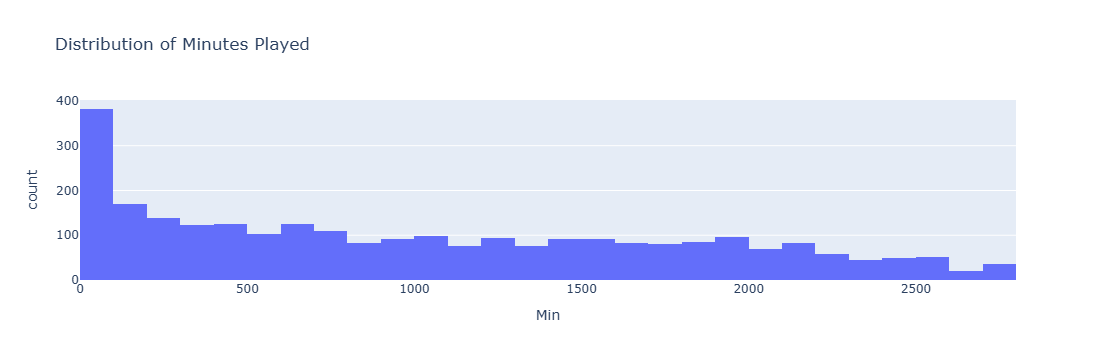

count    2731.000000
mean     1028.034420
std       794.819728
min         1.000000
25%       292.000000
50%       901.000000
75%      1689.500000
max      2790.000000
Name: Min, dtype: float64


In [15]:
fig = px.histogram(
    df_eda,
    x="Min",
    nbins=50,
    title="Distribution of Minutes Played"
)

fig.show()

print(df_eda["Min"].describe())

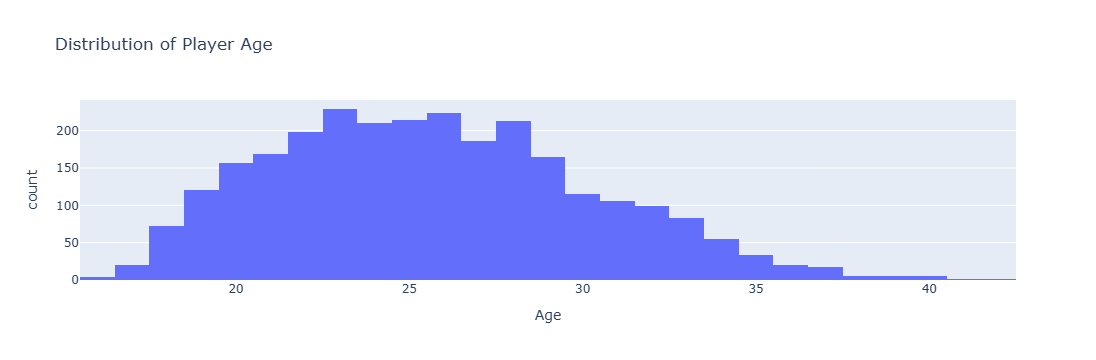

count    2730.000000
mean       25.675458
std         4.560993
min        16.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        42.000000
Name: Age, dtype: float64


In [16]:
fig = px.histogram(
    df_eda,
    x="Age",
    nbins=30,
    title="Distribution of Player Age"
)

fig.show()

print(df_eda["Age"].describe())

In [17]:
minutes_threshold = 500

df_active = df_eda[df_eda["Min"] >= minutes_threshold].copy()

print(f"Original players: {len(df_eda)}")
print(f"Players with at least {minutes_threshold} minutes: {len(df_active)}")
print(f"Players removed: {len(df_eda) - len(df_active)}")

display(df_active.head())

Original players: 2731
Players with at least 500 minutes: 1791
Players removed: 940


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,G+A-PK,Rk_stats_keeper,Nation_stats_keeper,Pos_stats_keeper,Comp_stats_keeper,Age_stats_keeper,Born_stats_keeper,MP_stats_keeper,Starts_stats_keeper,Min_stats_keeper,90s_stats_keeper,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Rk_stats_shooting,Nation_stats_shooting,Pos_stats_shooting,Comp_stats_shooting,Age_stats_shooting,Born_stats_shooting,90s_stats_shooting,Gls_stats_shooting,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK_stats_shooting,PKatt_stats_shooting,Rk_stats_playing_time,Nation_stats_playing_time,Pos_stats_playing_time,Comp_stats_playing_time,Age_stats_playing_time,Born_stats_playing_time,MP_stats_playing_time,Min_stats_playing_time,Mn/MP,Min%,90s_stats_playing_time,Starts_stats_playing_time,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Rk_stats_misc,Nation_stats_misc,Pos_stats_misc,Comp_stats_misc,Age_stats_misc,Born_stats_misc,90s_stats_misc,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,30,24,1975,21.9,4,3,7,4,0,0,1,0,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,21.9,4,41,15,36.6,1.87,0.68,0.10,0.27,0,0,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,30,1975,66,70.8,21.9,24,77.0,2,6,21.0,1,1.00,30,26,4,0.18,1.84,1,us USA,"MF,FW",eng Premier League,25-169,2000.0,21.9,1,0,0,17,43,5,35,13,22,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,638,7.1,2,0,2,2,0,0,0,0,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,ma MAR,"MF,FW",es La Liga,20-087,2006.0,7.1,2,16,4,25.0,2.26,0.56,0.13,0.50,0,0,5,ma MAR,"MF,FW",es La Liga,20-087,2006.0,20,638,32,23.6,7.1,4,75.0,1,16,21.0,10,1.55,16,11,5,0.71,0.62,3,ma MAR,"MF,FW",es La Liga,20-087,2006.0,7.1,0,0,0,5,3,2,26,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,943,10.5,2,0,2,0,2,2,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,dz ALG,MF,fr Ligue 1,26-143,1999.0,10.5,2,11,5,45.5,1.05,0.48,0.00,0.00,2,2,7,dz ALG,MF,fr Ligue 1,26-143,1999.0,13,943,73,37.4,10.5,11,81.0,4,2,25.0,0,1.38,12,13,-1,-0.10,0.59,5,dz ALG,MF,fr Ligue 1,26-143,1999.0,10.5,1,0,0,16,12,1,9,13,17,0
5,6,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32.0,1993.0,17,11,955,10.6,1,0,1,1,0,0,4,1,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,tn TUN,"DF,MF",fr Ligue 1,32-110,1993.0,10.6,1,5,1,20.0,0.47,0.09,0.20,1.00,0,0,8,tn TUN,"DF,MF",fr Ligue 1,32-110,1993.0,17,955,56,37.9,10.6,11,74.0,6,6,24.0,1,0.65,16,15,1,0.09,1.42,6,tn TUN,"DF,MF",fr Ligue 1,32-110,1993.0,10.6,4,1,1,16,14,0,28,10,8,0
6,7,Salis Abdul Samed,gh GHA,MF,Nice,fr Ligue 1,26.0,2000.0,14,9,663,7.4,0,0,0,0,0,0,3,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,gh GHA,MF,fr Ligue 1,26-014,2000.0,7.4,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,9,gh GHA,MF,fr Ligue 1,26-014,2000.0,14,663,47,26.3,7.4,9,64.0,1,5,17.0,10,1.14,13,15,-2,-0.27,0.70,7,gh GHA,MF,fr Ligue 1,26-014,2000.0,7.4,3,0,0,14,7,0,1,9,7,0


In [18]:
attacking_cols = ["Player", "Squad", "Comp", "Pos", "Min", "Gls", "Ast", "G+A", "Sh", "SoT"]

available_attacking_cols = [col for col in attacking_cols if col in df_active.columns]

top_attackers = df_active[available_attacking_cols].copy()

for col in ["Gls", "Ast", "G+A", "Sh", "SoT"]:
    if col in top_attackers.columns:
        top_attackers[col] = pd.to_numeric(top_attackers[col], errors="coerce")

display(top_attackers.sort_values("G+A", ascending=False).head(20))

,Player,Squad,Comp,Pos,Min,Gls,Ast,G+A,Sh,SoT
1265,Harry Kane,Bayern Munich,de Bundesliga,"FW,MF",2062,31,5,36,108,61
1901,Michael Olise,Bayern Munich,de Bundesliga,MF,2003,11,18,29,87,43
1055,Erling Haaland,Manchester City,eng Premier League,FW,2413,22,7,29,102,49
1630,Kylian Mbappé,Real Madrid,es La Liga,FW,2137,23,4,27,117,54
672,Luis Díaz,Bayern Munich,de Bundesliga,MF,2159,15,11,26,75,34
2553,Deniz Undav,Stuttgart,de Bundesliga,"FW,MF",1817,18,6,24,103,41
833,Bruno Fernandes,Manchester Utd,eng Premier League,MF,2434,8,16,24,73,21
2676,Lamine Yamal,Barcelona,es La Liga,"MF,FW",2128,14,9,23,106,34
2480,Igor Thiago,Brentford,eng Premier League,FW,2652,19,1,20,71,37
1592,Lautaro Martínez,Inter,it Serie A,FW,1945,16,4,20,86,35


In [19]:
per90_base_cols = ["Gls", "Ast", "G+A", "Sh", "SoT", "Crs", "Int", "TklW"]

for col in per90_base_cols:
    if col in df_active.columns:
        df_active[col] = pd.to_numeric(df_active[col], errors="coerce")
        df_active[f"{col}_per90"] = df_active[col] / df_active["90s"]

created_per90_cols = [col for col in df_active.columns if col.endswith("_per90")]

print("Created per-90 columns:")
print(created_per90_cols)

display(df_active[["Player", "Squad", "Pos", "Min"] + created_per90_cols].head())

Created per-90 columns:
['Gls_per90', 'Ast_per90', 'G+A_per90', 'Sh_per90', 'SoT_per90', 'Crs_per90', 'Int_per90', 'TklW_per90']


,Player,Squad,Pos,Min,Gls_per90,Ast_per90,G+A_per90,Sh_per90,SoT_per90,Crs_per90,Int_per90,TklW_per90
0,Brenden Aaronson,Leeds United,"MF,FW",1975,0.182648,0.136986,0.319635,1.872146,0.684932,1.598174,0.593607,1.004566
2,Jones El-Abdellaoui,Celta Vigo,"MF,FW",638,0.281690,0.000000,0.281690,2.253521,0.563380,3.661972,0.422535,0.422535
4,Himad Abdelli,Angers,MF,943,0.190476,0.000000,0.190476,1.047619,0.476190,0.857143,1.238095,1.619048
5,Ali Abdi,Nice,"DF,MF",955,0.094340,0.000000,0.094340,0.471698,0.094340,2.641509,0.943396,0.754717
6,Salis Abdul Samed,Nice,MF,663,0.000000,0.000000,0.000000,0.000000,0.000000,0.135135,1.216216,0.945946


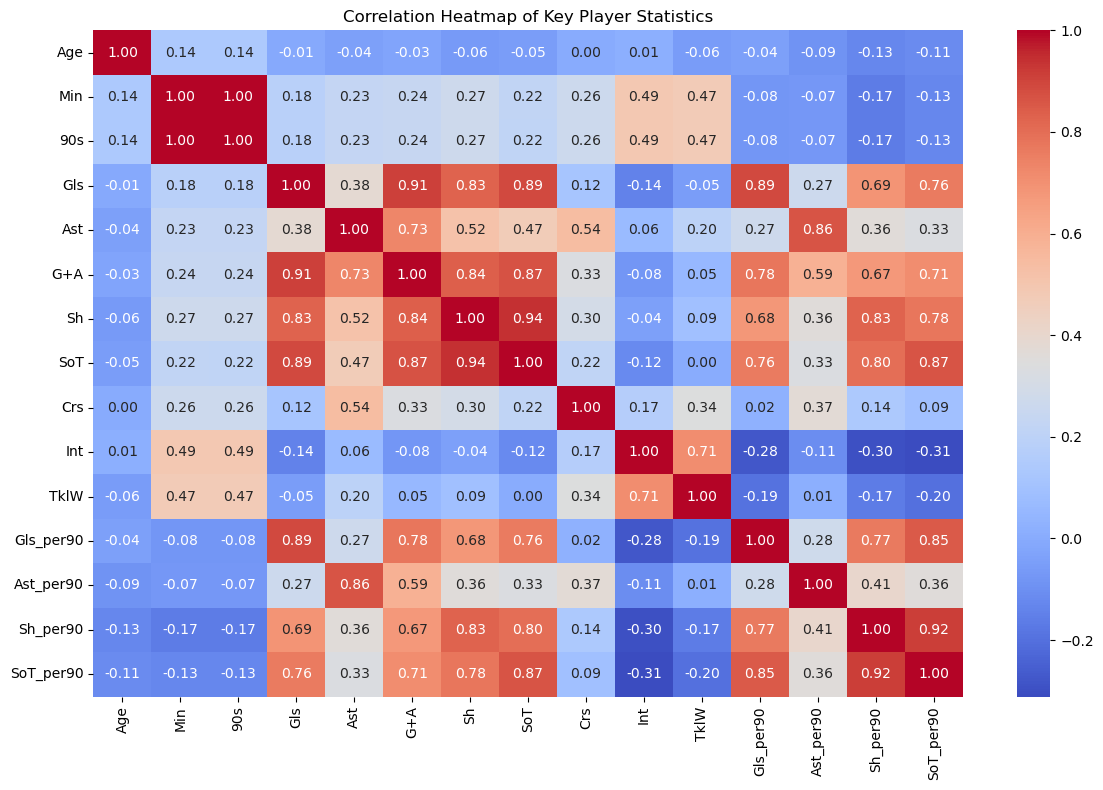

In [20]:
numeric_df = df_active.select_dtypes(include=["number"])

correlation_cols = [
    col for col in [
        "Age", "Min", "90s", "Gls", "Ast", "G+A", "Sh", "SoT",
        "Crs", "Int", "TklW", "Gls_per90", "Ast_per90", "Sh_per90", "SoT_per90"
    ]
    if col in numeric_df.columns
]

corr = numeric_df[correlation_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Player Statistics")
plt.tight_layout()
plt.show()

In [21]:
possible_value_columns = [
    col for col in df.columns 
    if "value" in col.lower() or "market" in col.lower() or "fee" in col.lower()
]

print("Possible market value columns:")
print(possible_value_columns)

Possible market value columns:
[]


In [22]:
output_path = "../data/eda_active_players_sample.csv"

df_active.to_csv(output_path, index=False)

print(f"EDA active player dataset saved to: {output_path}")
print(df_active.shape)

EDA active player dataset saved to: ../data/eda_active_players_sample.csv
(1791, 110)


In [ ]:
## EDA Summary

The initial exploration identified the main structure of the player dataset, including player demographics, leagues, positions, playing time, attacking metrics, defensive actions, and goalkeeper-specific variables.

A minimum minutes threshold was applied during exploratory analysis to reduce noise from players with limited appearances. This will support more reliable feature engineering and modelling in later notebooks.

The dataset contains several missing values, particularly in position-specific statistics such as goalkeeper metrics. These will be handled carefully in the cleaning stage rather than removed blindly.

The next notebook will focus on data cleaning, feature engineering, and preparing a modelling-ready dataset.

In [40]:
valuations_with_names = players_df.merge(
    valuations_df,
    on="player_id",
    how="inner"
)

In [41]:
valuations_with_names = valuations_with_names.drop_duplicates(subset="player_id")

In [43]:
import unidecode

def clean_name(name):
    name = str(name)
    name = unidecode.unidecode(name)
    name = name.lower().strip()
    return name

df["clean_name"] = df["Player"].apply(clean_name)
valuations_with_names["clean_name"] = valuations_with_names["name"].apply(clean_name)

In [44]:
final_df = df.merge(
    valuations_with_names,
    on="clean_name",
    how="inner"
)

In [45]:
print("Original dataset:", len(df))
print("Final merged dataset:", len(final_df))

final_df[["Player", "name"]].head(20)

Original dataset: 2731
Final merged dataset: 2583


,Player,name
0,Brenden Aaronson,Brenden Aaronson
1,Zach Abbott,Zach Abbott
2,Jones El-Abdellaoui,Jones El-Abdellaoui
3,Himad Abdelli,Himad Abdelli
4,Himad Abdelli,Himad Abdelli
5,Ali Abdi,Ali Abdi
6,Salis Abdul Samed,Salis Abdul Samed
7,Saud Abdulhamid,Saud Abdulhamid
8,Tay Abed,Tay Abed
9,Laurent Abergel,Laurent Abergel


In [46]:
final_df["Player"].value_counts().head(10)

Player
João Pedro           10
Adama Traoré          8
Marcão                5
Pablo                 5
Pedro                 5
Rômulo                5
Roberto Férnandez     4
Álvaro García         4
Idrissa Guèye         4
Ladislav Krejčí       4
Name: count, dtype: int64

In [47]:
output_path = "../data/players_with_valuations.csv"

final_df.to_csv(output_path, index=False)

print("Saved merged dataset successfully.")
print(final_df.shape)

Saved merged dataset successfully.
(2583, 134)
